## Assignment 1 — Exploring FAISS (Local Vector Search)

### Goal:

Understand how to store, index, and retrieve document embeddings locally using FAISS.

### Tasks:
- Install faiss-cpu and sentence-transformers.
- Create a mini-corpus (10–20 short texts on a topic like “AI for environment”).
- Generate embeddings using SentenceTransformer("all-MiniLM-L6-v2").
- Store them in a FAISS index (IndexFlatL2).
- Search for the top-k most similar documents for a given query.
- Plot similarity distances (e.g., bar chart or cosine heatmap).

### Reflection:
- How does L2 distance differ from cosine similarity?
- How would results change if you normalize embeddings?

### Deliverables:
-.ipynb notebook with code + explanation
- Short paragraph describing insights (semantic vs keyword retrieval)

In [1]:
!pip install faiss-cpu sentence-transformers matplotlib chromadb pinecone-client


   -------------------- ------------------- 1/2 [pinecone-client]
   ---------------------------------------- 2/2 [pinecone-client]



c:\Users\mohit\Documents\NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total documents in index: 6

Query: How is artificial intelligence helping the ocean?
Rank 1 (Doc 0, Distance: 0.6698): AI is being used to monitor ocean plastic pollution.
Rank 2 (Doc 3, Distance: 1.0155): Satellites use AI to track illegal fishing fleets.
Rank 3 (Doc 4, Distance: 1.3098): Smart grids use AI to balance renewable energy loads.


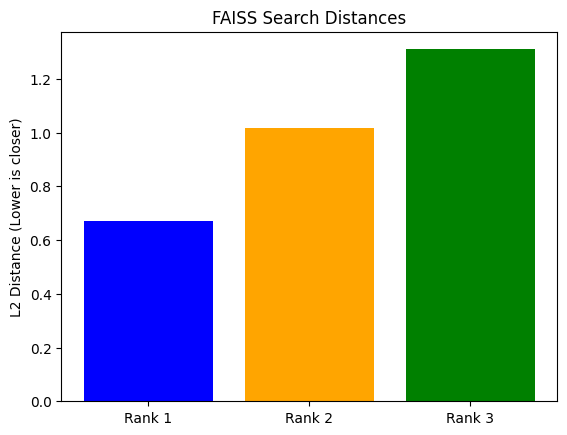

In [2]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import matplotlib.pyplot as plt

texts = [
    "AI is being used to monitor ocean plastic pollution.",
    "Machine learning models optimize wind turbine positioning.",
    "Deep learning predicts areas at high risk of deforestation.",
    "Satellites use AI to track illegal fishing fleets.",
    "Smart grids use AI to balance renewable energy loads.",
    "My cat likes to sleep in the sun all day long." # Noise document
]

model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(texts)

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)
print(f"Total documents in index: {index.ntotal}")


query = "How is artificial intelligence helping the ocean?"
query_embedding = model.encode([query])
k = 3
distances, indices = index.search(query_embedding, k)

print(f"\nQuery: {query}")
for i in range(k):
    doc_idx = indices[0][i]
    print(f"Rank {i+1} (Doc {doc_idx}, Distance: {distances[0][i]:.4f}): {texts[doc_idx]}")

plt.bar([f"Rank {i+1}" for i in range(k)], distances[0], color=['blue', 'orange', 'green'])
plt.ylabel("L2 Distance (Lower is closer)")
plt.title("FAISS Search Distances")
plt.show()

## Assignment 2 — Building a Mini Knowledge Base with Chroma

### Goal:

Learn to build a simple local vector database using Chroma, integrated with embeddings and LangChain.

### Tasks:
- Install chromadb and sentence-transformers.
- Create a collection in Chroma called "ai_water_docs".
- Add at least 10 documents with text + metadata (e.g., title, source).
- Query the collection with 3 different questions (e.g., “How does AI detect pollution?”).
- Visualize which documents are retrieved (e.g., top 3).
- Optional: integrate with LangChain for a small RAG-style Q&A.

### Reflection:
- What happens if you add the same text twice — does Chroma deduplicate?
- How can you filter by metadata (e.g., only “scientific” docs)?

### Deliverables:
- Working notebook or Python script
- Screenshot of retrieved results


In [3]:
import chromadb


client = chromadb.Client()

if "ai_water_docs" in [c.name for c in client.list_collections()]:
    client.delete_collection("ai_water_docs")
    
collection = client.create_collection(name="ai_water_docs")


docs = [
    "AI algorithms can analyze water samples to detect heavy metal pollution.",
    "Smart sensors in city pipes predict water leaks using machine learning.",
    "Autonomous drones clean up river waste automatically.",
    "Machine learning forecasts seasonal droughts for farmers."
]
metadatas = [
    {"title": "Heavy Metal Study", "source": "scientific"},
    {"title": "Smart City Tech", "source": "industry"},
    {"title": "Drone Tech", "source": "news"},
    {"title": "AgriAI", "source": "scientific"}
]
ids = ["doc1", "doc2", "doc3", "doc4"]

collection.add(documents=docs, metadatas=metadatas, ids=ids)


results = collection.query(
    query_texts=["How does AI detect pollution?"],
    n_results=2,
    # Example of metadata filtering!
    where={"source": "scientific"} 
)

print("Retrieved Documents:")
for doc, meta in zip(results['documents'][0], results['metadatas'][0]):
    print(f"- [{meta['title']}] {doc}")

Retrieved Documents:
- [Heavy Metal Study] AI algorithms can analyze water samples to detect heavy metal pollution.
- [AgriAI] Machine learning forecasts seasonal droughts for farmers.


## Assignment 3 — Using Pinecone (Cloud Vector Database)

### Goal:

Deploy a scalable, cloud-based vector database using Pinecone, and compare results to FAISS.

### Tasks:
- Create a free Pinecone account → get API key.
- Install the client: pip install pinecone-client.
- Initialize Pinecone and create an index called "student-demo".
- Insert at least 50 documents + embeddings.
- Write code to query Pinecone for semantic matches.
- Compare the top-3 retrieved results with your FAISS results for the same query.

### Reflection:
- How does latency compare to FAISS (local)?
- What advantages does a managed vector DB provide?

### Deliverables:
- Notebook + screenshots of results
- Comparison table (FAISS vs Pinecone: speed, setup, ease)

In [5]:
!pip uninstall pinecone-client -y
!pip install pinecone

Found existing installation: pinecone-client 6.0.0
Uninstalling pinecone-client-6.0.0:
  Successfully uninstalled pinecone-client-6.0.0
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   -------------------------------- ------- 2.1/2.6 MB 9.8 MB/s eta 0:00:01
   ---------------------------------------- 2.6/2.6 MB 6.5 MB/s  0:00:00

   -------------------- ------------------- 1/2 [pinecone]
   -------------------- ------------------- 1/2 [pinecone]
   -------------------- ------------------- 1/2 [pinecone]
   -------------------- ------------------- 1/2 [pinecone]
   -------------------- ------------------- 1/2 [pinecone]
   -------------------- ------------------- 1/2 [pinecone]
   -------------------- ------------------- 1/2 [pinecone]
   -------------------- ------------------- 1/2 [pinecone]
   ---------------------------------------- 2/2 [pinecone]



In [6]:

from pinecone import Pinecone, ServerlessSpec
from sentence_transformers import SentenceTransformer

# NOTE: Replace with your actual free Pinecone API key!
pc = Pinecone(api_key="pcsk_4Loqzf_HUxTNqsQVyKy1ubJ64TpwqEQUgdG3pPbgs2RPdxoq858XEmPNZkscZMGs1KbLFL")

index_name = "student-demo"
dimension = 384 # Dimension for all-MiniLM-L6-v2

# Create index if it doesn't exist
if index_name not in pc.list_indexes().names():
    pc.create_index(
        name=index_name,
        dimension=dimension,
        metric="cosine", # Better for semantic search
        spec=ServerlessSpec(cloud="aws", region="us-east-1")
    )

index = pc.Index(index_name)

# Prepare data (Upserting requires ID, vector, and optional metadata)
model = SentenceTransformer("all-MiniLM-L6-v2")
doc_text = "Pinecone allows for highly scalable cloud vector search."
vector = model.encode(doc_text).tolist() # Pinecone expects standard python lists

index.upsert(
    vectors=[
        {"id": "cloud_doc_1", "values": vector, "metadata": {"text": doc_text}}
    ]
)

# Query
query_vec = model.encode("How do I scale vector databases?").tolist()
result = index.query(vector=query_vec, top_k=1, include_metadata=True)
print("Pinecone Result:", result['matches'][0]['metadata']['text'])

Pinecone Result: Pinecone allows for highly scalable cloud vector search.


### Bonus / Advanced Assignments (Optional)

## Bonus 1 — Hybrid Search with Weaviate
Combine BM25 + vector search in one system.

Tasks:
1. Launch Weaviate (Docker or Cloud)
2. Insert sample texts into a "ResearchDoc" class
3. Run nearText (semantic) vs bm25 (keyword) queries
4. Compare which retrieves better answers


## Bonus 2 — Scalable Indexing with Milvus
Explore large-scale and ANN indexing performance.

Tasks:
1. Run Milvus locally or use Zilliz Cloud
2. Insert ~1 000 vectors into a collection
3. Build IVF or HNSW index
4. Measure query speed before/after indexing

## Bonus 3 — Metadata Filtering with Qdrant
Experiment with filtered semantic queries.

Tasks:
1. Run Qdrant (Docker or in-memory)
2. Insert 20 vectors + metadata (year, source)
3. Query semantically + apply filters (e.g., year > 2021)
4. Compare results with and without filters